# Notebook 04 - Bibliographic Visualization

In this nootebook, you will find the plots regardin the bibliographic informations contained in the dataframes. The plots include, most magazines published, most collaborations, publications per year, types of stories and informations about the entities apparitions. 

# 0. Setup

In [224]:
# Libraries

# General
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis


# File management
from pathlib import Path                  # imports path tools from Pathlib for working with file paths
import os                               # imports the OS library for interacting with the operating system

def find_project_root(start=Path.cwd(), marker='data'): # defines a function to find the project root directory by looking for a specific marker (default is 'data')
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

from tools import text_tools # tools for text processing
from tools import dataframe_tools as dftools # tools for dataframe processing

In [225]:
# Plotting Options
from matplotlib import pyplot as plt                           # imports the Pyplot module from the Matplotlib library for plotting
plt.rcParams['text.usetex'] = True                             # enables LaTeX rendering for text in plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # LaTeX preamble

# Set global font sizes for all plots in the notebook
plt.rcParams.update({
    'axes.labelsize': 14,    # x and y labels
    'axes.titlesize': 16,    # title
    'xtick.labelsize': 12,   # x-axis tick labels
    'ytick.labelsize': 12,    # y-axis tick labels
    'axes.titlesize': 25    # title
})


In [226]:
biblio = text_tools.bibliography()  # defines a bibliography object
print( biblio.files )               # lists the files in the directory

['dreams_in_the_witch.txt', 'ex_oblivione.txt', 'poetry_of_gods.txt', 'doorstep.txt', 'colour_out_of_space.txt', 'iranon.txt', 'street.txt', 'arthur_jermyn.txt', 'crawling_chaos.txt', 'ulthar.txt', 'azathoth.txt', 'shadow_out_of_time.txt', 'haunter.txt', 'martins_beach.txt', 'tree.txt', 'whisperer.txt', 'moon_bog.txt', 'unnamable.txt', 'beast.txt', 'alchemist.txt', 'terrible_old_man.txt', 'nameless.txt', 'reanimator.txt', 'celephais.txt', 'gates_of_silver_key.txt', 'medusas_coil.txt', 'dagon.txt', 'picture_house.txt', 'memory.txt', 'white_ship.txt', 'erich_zann.txt', 'tomb.txt', 'temple.txt', 'he.txt', 'pickman.txt', 'silver_key.txt', 'clergyman.txt', 'old_folk.txt', 'from_beyond.txt', 'descendent.txt', 'nyarlathotep.txt', 'vault.txt', 'hypnos.txt', 'polaris.txt', 'book.txt', 'shunned_house.txt', 'pharoahs.txt', 'randolph_carter.txt', 'innsmouth.txt', 'charles_dexter_ward.txt', 'dunwich.txt', 'festival.txt', 'other_gods.txt', 'redhook.txt', 'hound.txt', 'outsider.txt', 'mountains_of_ma

# 1. Dataframe plots

In [227]:
df_works = pd.read_csv('data/gold/lovecraft_works.csv')
df_works['year_written'] = df_works['year_written'].astype('Int64')
df_works

,title,magazine,year_published,collaboration,date_written,year_written,form
0,the_alchemist,the_united_amateur,1916,NaN,1908,1908,short_story
1,a_reminiscence_of_dr_samuel_johnson,the_united_amateur,1917,NaN,Sum-early Fall 1917,1917,short_story
2,the_beast_in_the_cave,the_vagrant,1918,NaN,NaN,<NA>,short_story
3,beyond_the_wall_of_sleep,pine_cones,1919,NaN,Spr 1919,1919,short_story
4,the_white_ship,the_united_amateur,1919,NaN,c. Oct 1919,1919,short_story
...,...,...,...,...,...,...,...
94,bothon,amazing_stories,1946,whitehead_henry_s,1930,1930,short_story
95,the_dreamquest_of_unknown_kadath,the_arkham_sampler,1948,NaN,Oct 1926-22 Jan 1927,1927,novella
96,sweet_ermengarde_or_the_heart_of_a_country_girl,mirage,1965,NaN,NaN,<NA>,short_story
97,ex_oblivione,magazine_of_horror,1968,NaN,1920 – Mar 1921,1921,short_story


We now analyze several aspects of Lovecraft's bibliography, namely:
    
    1. Publication History;
    2. Magazines;
    3. Types of Story;
    4. Collaborations.

## 1.1 Writing History

In this section we visualize the number of writings per year. 

In [228]:
df_writings = df_works['year_written'].value_counts().to_frame()
df_writings = df_writings.reset_index()
df_writings.columns = ['year_written', 'texts']
df_writings = df_writings.sort_values(by = 'year_written')
df_writings = df_writings.reset_index(drop = True)
df_writings

,year_written,texts
0,1908,1
1,1917,3
2,1918,1
3,1919,8
4,1920,11
5,1921,8
6,1922,6
7,1923,4
8,1924,1
9,1925,3


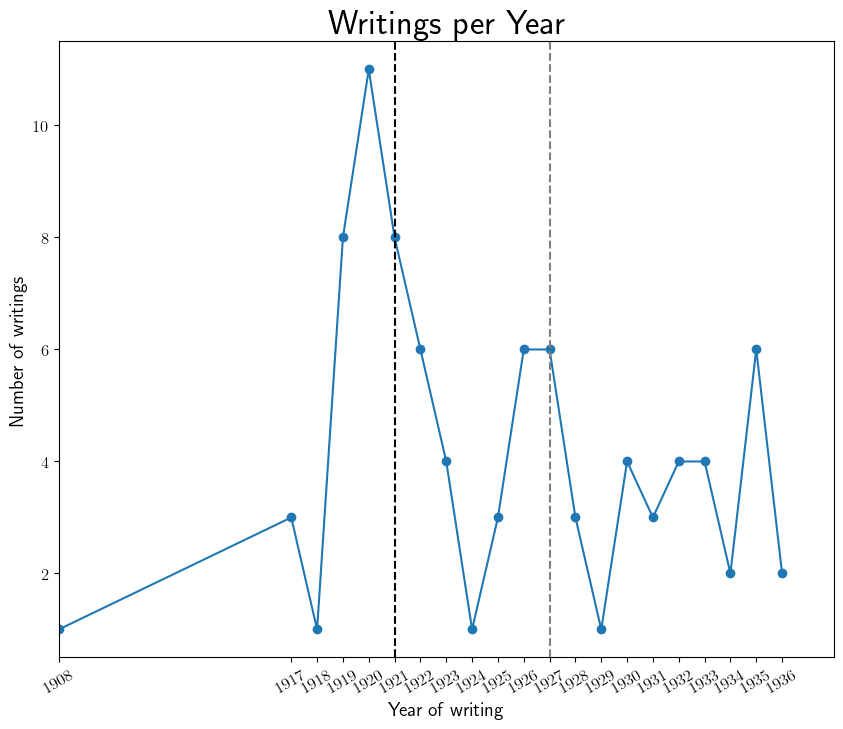

In [229]:
# bar plot
df_writings.plot(x="year_written",   # x axis
              y="texts",            # y axis
              legend=False,         # no legend
              figsize=(10,8),       # size of figure
              marker='o'            # sets marker to •
              )

# vertical lines
plt.axvline( x = 1921, color='black', linestyle='--' )  # death of mother
plt.axvline( x = 1927, color='grey', linestyle='--' )   # divorce

# formatting
plt.xticks(rotation=30)                 # rotation angle of x axis labels
plt.xlabel('Year of writing')       # x axis label
plt.ylabel('Number of writings')    # x axis label
plt.title('Writings per Year')
plt.xticks( df_writings['year_written'].tolist() )            # x-ticks (years)
plt.xlim( min( df_writings['year_written'].tolist() ), 1938 ) # x lim to remove-post mortem for visualization

# saves the figure
plt.savefig('plots/writing_per_year.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)

# displays the plot
plt.show()

# mudar forma da série temporal e colocar ano dos eventos

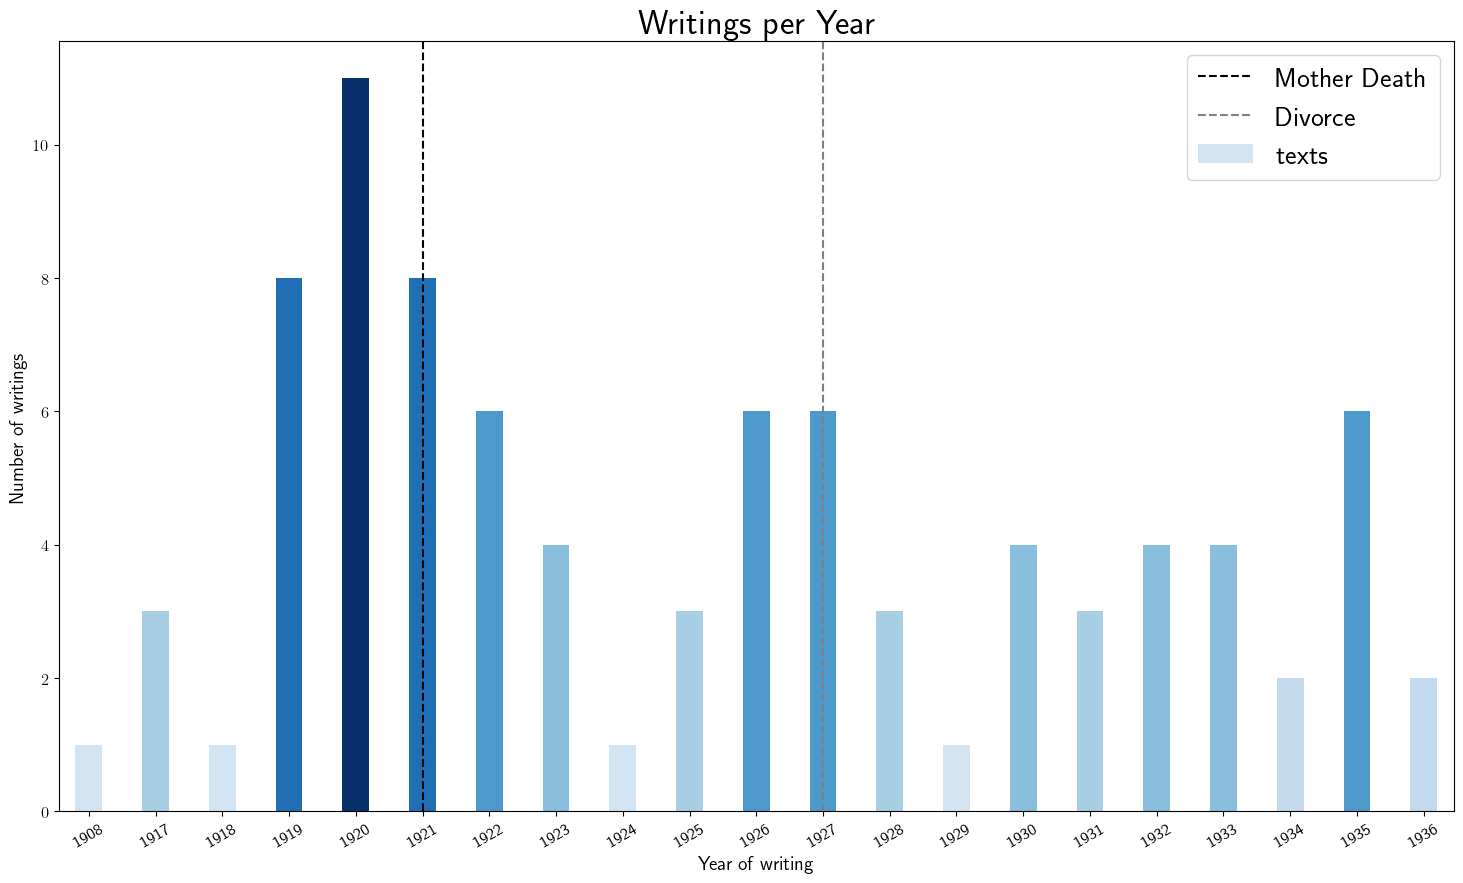

In [230]:
# sorts by year
df_writings = df_writings.sort_values('year_written')

# blue pallete
colors = plt.cm.Blues(0.1 + 0.9 * df_writings['texts'] / df_writings['texts'].max())  

# plot
df_writings.plot(kind='bar',
              width=0.4,
              x="year_written",   # x axis
              y="texts",            # y axis
              legend=False,         # no legend
              figsize=(18,10),       # size of figure
              color = colors
              )

# vertical lines (now using bar index positions)
plt.axvline(x=df_writings['year_written'].tolist().index(1921), label='Mother Death' , color='black', linestyle='--')  # death of mother
plt.axvline(x=df_writings['year_written'].tolist().index(1927), label='Divorce' , color='grey', linestyle='--')   # divorce

# formatting
plt.xticks(rotation=30)                 # rotation angle of x axis labels
plt.xlabel('Year of writing')       # x axis label
plt.ylabel('Number of writings')    # x axis label
plt.title('Writings per Year')      # title
#plt.xticks( df_writings['year_written'].tolist() )            # x-ticks (years)
#plt.xlim( min( df_writings['year_written'].tolist() ), 1938 ) # x lim to remove-post mortem for visualization
plt.legend(fontsize = 20) # displays the legend

# saves the figure
plt.savefig('plots/writing_per_year_bar.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)

# displays the plot
plt.show()

## 1.2 Publication History


In this section we visualize the number of published texts per year. Note that some of Lovecraft's work was published after his death in 1937. Therefore, one should keep in mind that the publication order is not the same as the order in which the stories were written.

In [231]:
# df organized per year
df_years = df_works['year_published'].value_counts().to_frame()   # counts the number of entries per year
df_years = df_years.reset_index()                                 # resets the index
df_years.columns = ['year_published','Texts']                     # column names
df_years = df_years.sort_values('year_published')                 # sorts by year
df_years = df_years.reset_index(drop=True)                        # resets the again index, to be consistent with year

df_years

,year_published,Texts
0,1916,1
1,1917,1
2,1918,1
3,1919,5
4,1920,7
5,1921,6
6,1922,4
7,1923,4
8,1924,6
9,1925,5


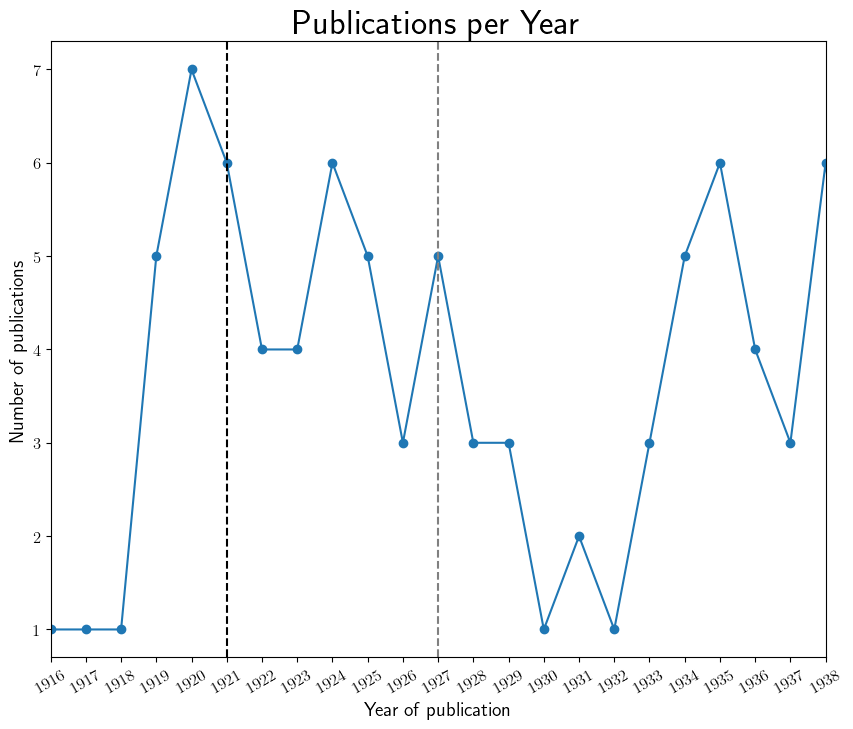

In [232]:
# bar plot
df_years.plot(x="year_published",   # x axis
              y="Texts",            # y axis
              legend=False,         # no legend
              figsize=(10,8),       # size of figure
              marker='o'            # sets marker to •
              )

# vertical lines
plt.axvline( x = 1921, color='black', linestyle='--' )  # death of mother
plt.axvline( x = 1927, color='grey', linestyle='--' )   # divorce

# formatting
plt.xticks(rotation=30)                 # rotation angle of x axis labels
plt.xlabel('Year of publication')       # x axis label
plt.ylabel('Number of publications')    # x axis label
plt.title('Publications per Year')
plt.xticks( df_years['year_published'].tolist() )            # x-ticks (years)
plt.xlim( min( df_years['year_published'].tolist() ), 1938 ) # x lim to remove-post mortem for visualization

# saves the figure
plt.savefig('plots/publication_per_year.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)

# displays the plot
plt.show()

# mudar forma da série temporal e colocar ano dos eventos

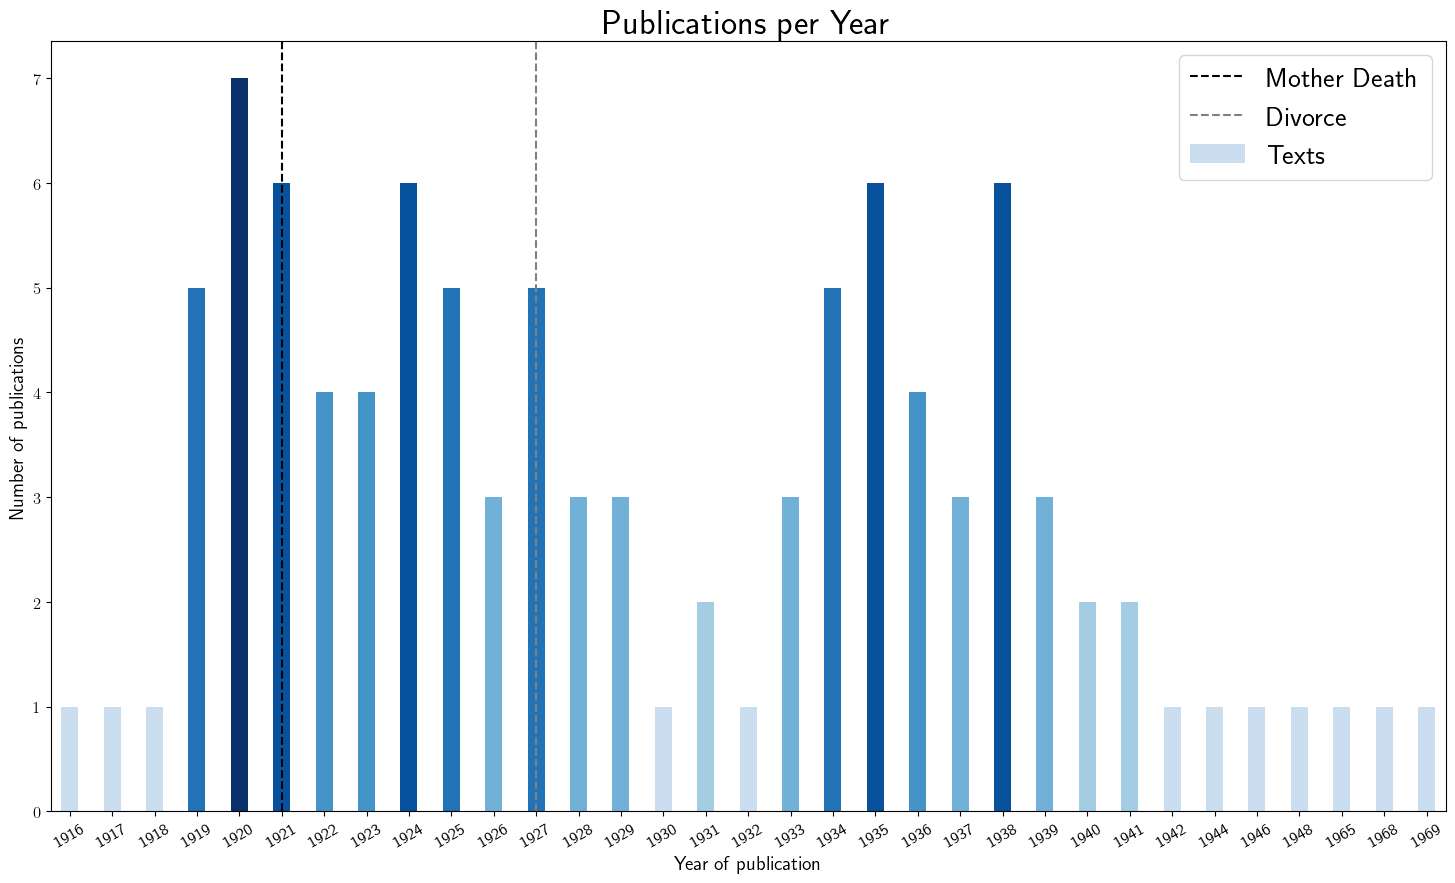

In [233]:
# sorts by year
df_years = df_years.sort_values('year_published')

# blue pallete
colors = plt.cm.Blues(0.1 + 0.9 * df_years['Texts'] / df_years['Texts'].max())  

# plot
df_years.plot(kind='bar',
              width=0.4,
              x="year_published",   # x axis
              y="Texts",            # y axis
              legend=False,         # no legend
              figsize=(18,10),       # size of figure
              color = colors
              )

# vertical lines (now using bar index positions)
plt.axvline(x=df_years['year_published'].tolist().index(1921), label='Mother Death' , color='black', linestyle='--')  # death of mother
plt.axvline(x=df_years['year_published'].tolist().index(1927), label='Divorce' , color='grey', linestyle='--')   # divorce

# formatting
plt.xticks(rotation=30)                 # rotation angle of x axis labels
plt.xlabel('Year of publication')       # x axis label
plt.ylabel('Number of publications')    # x axis label
plt.title('Publications per Year')      # title
#plt.xticks( df_years['year_published'].tolist() )            # x-ticks (years)
#plt.xlim( min( df_years['year_published'].tolist() ), 1938 ) # x lim to remove-post mortem for visualization
plt.legend(fontsize = 20) # displays the legend

# saves the figure
plt.savefig('plots/publication_per_year_bar.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)

# displays the plot
plt.show()

## 1.2 Magazines


In this section we plot the magazines with most publications in Lovecraft's career.

In [234]:
# occurence of magazine DataFRame
occurrence = df_works['magazine'].value_counts().to_frame()   # creates a magazine DataFrame
df_occurrence = occurrence.reset_index()                      # resets the index
df_occurrence.columns = ['magazine','Publications']           # column names

# writes the title in standard form
df_occurrence['magazine'] = df_occurrence['magazine'].apply(dftools.unnormalize_title)

# displays the DataFrame
df_occurrence

,magazine,Publications
0,Weird Tales,41
1,The United Amateur,6
2,The Vagrant,5
3,The Tryout,4
4,The National Amateur,4
5,Leaves,4
6,The Wolverine,3
7,The Fantasy Fan,3
8,The Californian,3
9,Astounding Stories,2


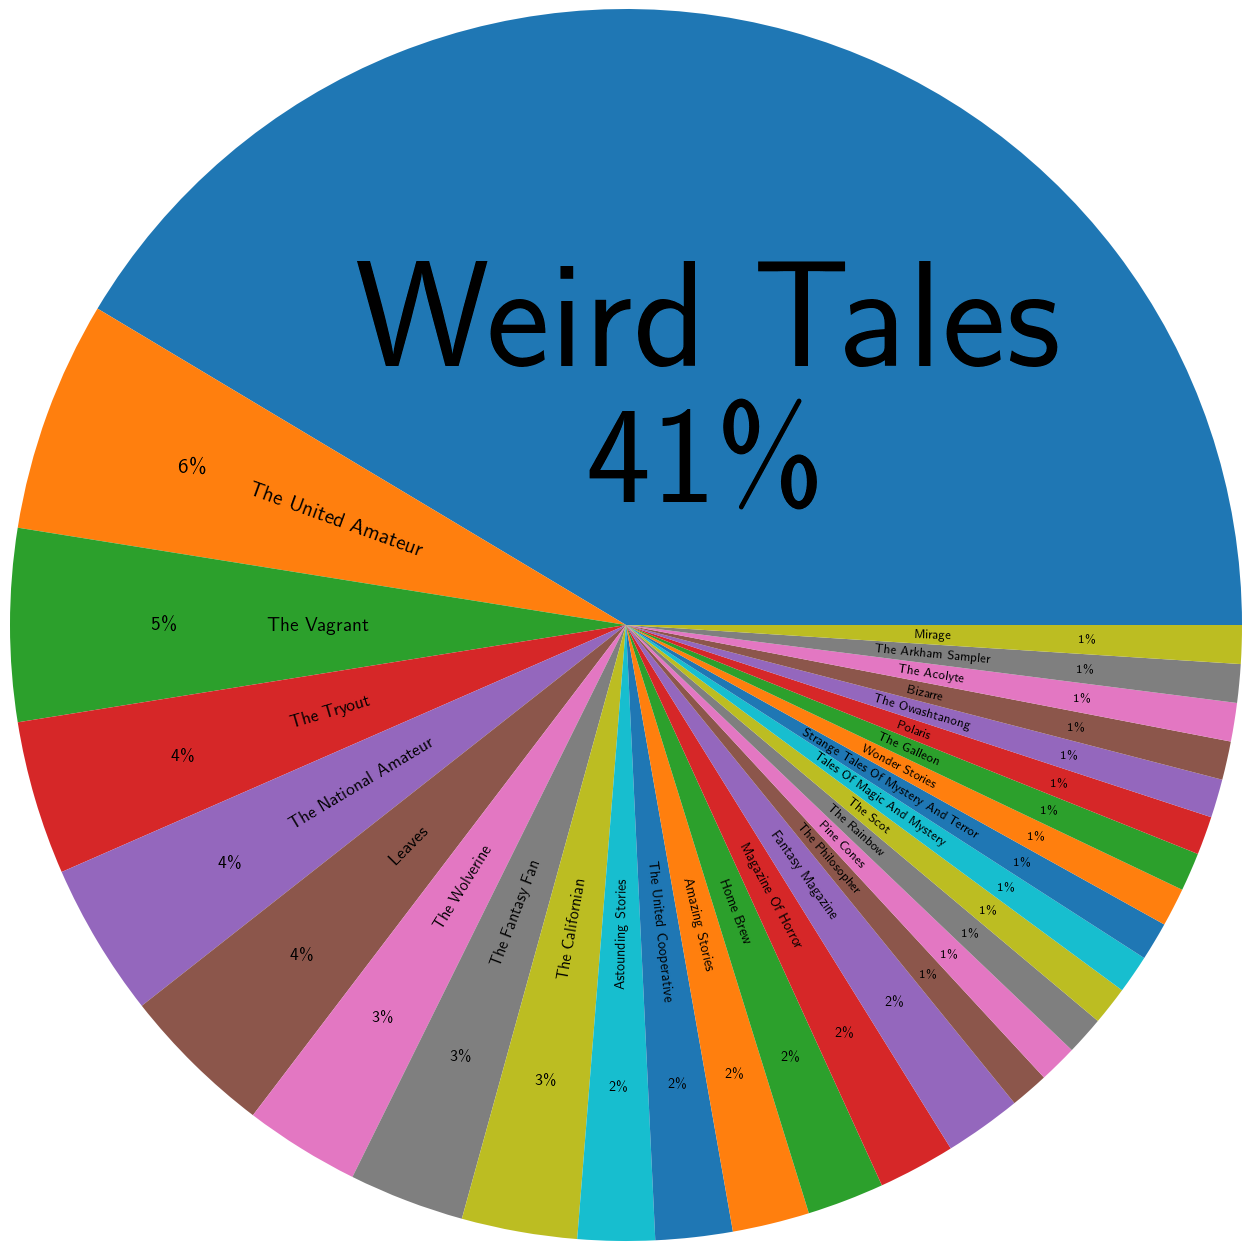

In [235]:
# Custom calibration factor for text sizes (adjust this value)
text_size_scale = 1.5   # increase or decrease to scale all dynamic text sizes

# generates a figure
fig, ax = plt.subplots(figsize = (10,10))

# Pie Plot
wedges, texts, autotexts = ax.pie(
    df_occurrence['Publications'],      # number of publications
    labels=df_occurrence['magazine'],   # labels (magazines)
    radius=2,                           # radius of circle
    autopct="%1.0f%%",                  # auto percentage
    labeldistance=0.5,                  # label distance
    pctdistance=0.75                    # percentage distance
)

# Rotates labels and percentages with a single loop
for wedge, text, autotext in zip(wedges, texts, autotexts):
    angle = (wedge.theta1 + wedge.theta2) / 2

    # rotation
    if 90 < angle < 270:
        angle += 180

    # implements the rotation
    text.set_rotation(angle)
    text.set_horizontalalignment('center')

    # scales font size with percentage and global calibration
    percentage = (wedge.theta2 - wedge.theta1) / 360 * 100
    text.set_fontsize((5 + percentage * 0.9) * text_size_scale)

    # keeps the percentage with the exact same angle as the text
    autotext.set_horizontalalignment('center')
    autotext.set_verticalalignment('center')
    autotext.set_fontsize((5 + percentage * 0.9) * text_size_scale)

    # places the percentage below the text only for Weird Tales
    x, y = text.get_position()
    theta = np.deg2rad(angle)

    # Weird Tales case
    if text.get_text() == 'Weird Tales':
        
        # forces the angles to be zero
        theta = 0
        angle = 0

        # implements the angle
        text.set_rotation(angle)
        autotext.set_rotation(angle)
        
        # font sizes
        text.set_fontsize(110)
        autotext.set_fontsize(100)

        # positioning of text
        autotext.set_position((x, y - 0.25))
        autotext.set_verticalalignment('top')

# saves the figure
plt.savefig('plots/magazines_pie_plot.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)

# displays the plot
plt.show()

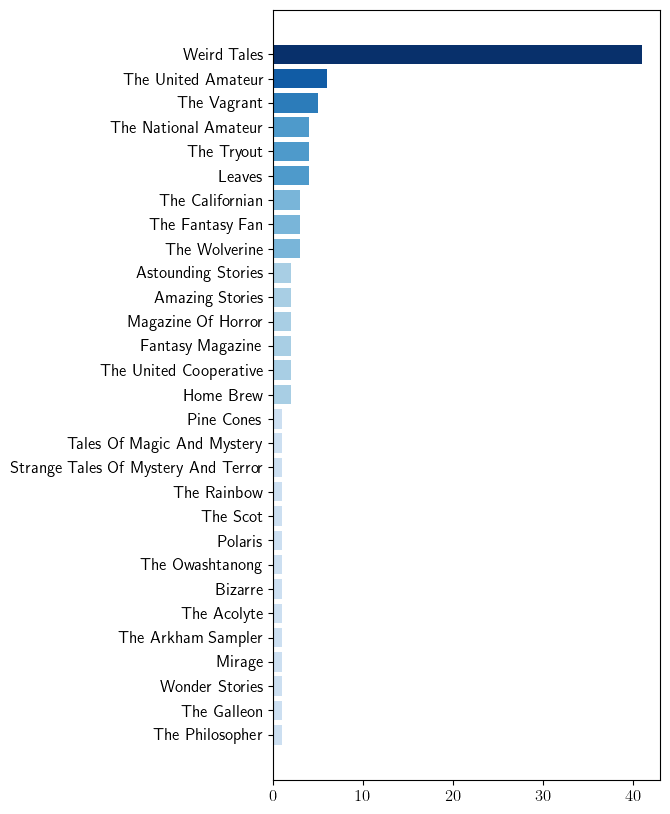

In [236]:
# bar plot 
df_occurrence = df_occurrence.sort_values('Publications')  # counts the number of values

# creates a figure
fig, ax = plt.subplots(figsize = (5,10)) 

# blue pallete
colors = plt.cm.Blues(0.1 + 5 * df_occurrence['Publications'] / df_occurrence['Publications'].max())  

# horizontal bar plot
ax.barh(
       df_occurrence['magazine'],       # magazine information
       df_occurrence['Publications'],   # number of publications
       color = colors                   # color map
       )


# saves the figure
plt.savefig('plots/magazines_bar_plot.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)  

# displays the plot
plt.show()

## 1.3 Types of Story


In this section we analyze the proportion of each type of story in Lovecraft's work.

In [237]:
# types of story Dataframe
df_form = df_works['form'].value_counts().to_frame()                 # counts the number of entries
df_form = df_form.reset_index()                                      # resets the index
df_form.columns = ['Type','Number of Texts']                                   # column names
df_form['Type'] = df_form['Type'].apply(dftools.unnormalize_title)   # writes title in usual form

# displays the DataFrame
df_form                                                                 

,Type,Number of Texts
0,Short Story,83
1,Novella,7
2,Fragment,6
3,Flash Fiction,1
4,Letter Excerpt,1
5,Novel,1


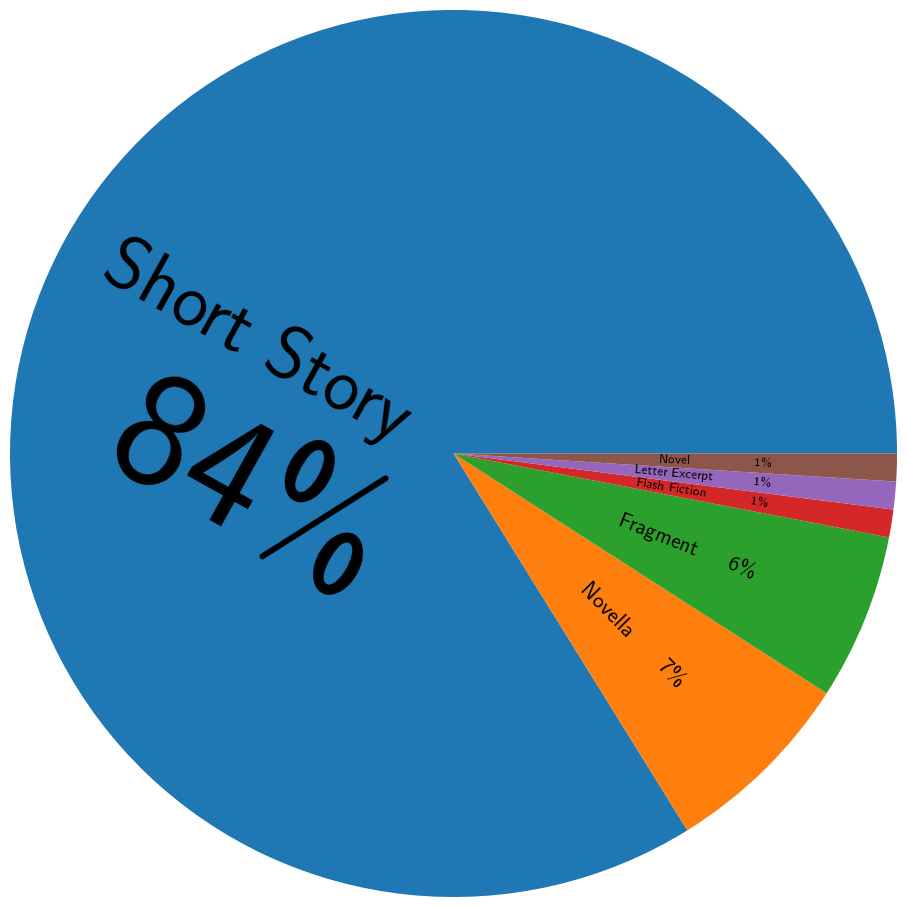

In [238]:
# Custom calibration factor for text sizes (adjust this value)
text_size_scale = 1.5   # increase or decrease to scale all dynamic text sizes

# generates a figure
fig, ax = plt.subplots(  )

# Pie Plot
wedges, texts, autotexts = ax.pie(
    df_form['Number of Texts'],
    labels=df_form['Type'],             # information for pie plot
    radius=3,                           # circle radius
    autopct="%1.0f%%",                  # auto percentage
    labeldistance=0.5,                  # label distance from the center
)

# Rotates labels and percentages with a single loop
for wedge, text, autotext in zip(wedges, texts, autotexts):
    angle = (wedge.theta1 + wedge.theta2) / 2

    # rotation
    if 90 < angle < 270:
        angle += 180

    # implements the rotation
    text.set_rotation(angle)
    text.set_horizontalalignment('center')

    # scale font size with percentage and global calibration
    percentage = (wedge.theta2 - wedge.theta1) / 360 * 100
    text.set_fontsize((5 + percentage * 0.9) * text_size_scale)

    # keeps the percentage with the exact same angle as the text
    autotext.set_rotation(angle)
    autotext.set_horizontalalignment('center')
    autotext.set_verticalalignment('center')
    autotext.set_fontsize((5 + percentage * 0.9) * text_size_scale)

    # places the percentage below the text only for Short Story
    x, y = text.get_position()
    theta = np.deg2rad(angle)

    # Short Story case
    if text.get_text() == 'Short Story':
        text.set_fontsize( 55 )
        autotext.set_position((x + 0.12 * np.sin(theta), y - 0.12 * np.cos(theta)))
        autotext.set_verticalalignment('top')
    
    # other cases
    else:
        eps = 0.6 # distance
        autotext.set_position((x + eps * np.cos(theta), y + eps * np.sin(theta)))

# saves the figure
plt.savefig('plots/types_plot.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)

# displays the plot
plt.show()

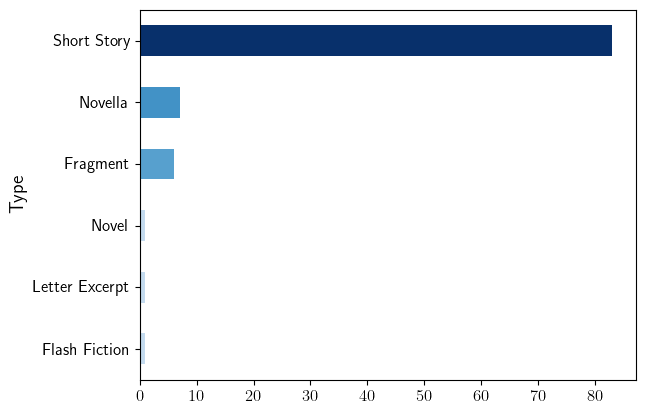

In [239]:
# sorts the DataFrame per number of texts
df_form = df_form.sort_values('Number of Texts')    

# blue palette
colors = plt.cm.Blues(0.2 + 5 * df_form['Number of Texts'] / df_form['Number of Texts'].max())

# generates a horizontal bar plot
df_form.plot(kind='barh', x='Type', y='Number of Texts', legend=False, color=colors)

# saves the figure
plt.savefig('plots/forms_bar_plot.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)

# displays the plot
plt.show()

## 1.4 Collaborations


In this section we analyze the most common collaborators during Lovecraft's career.

In [240]:
# dictionary to clean the names of the collaborators
name_mapping = {
    'talman_wilfred_blanch': 'Wilfred Blanch Talman',
    'with_moore_c_l': 'C. L. Moore',
    'houdini_harry': 'Harry Houdini',
    'with_price_e_hoffmann': 'E. Hoffmann Price',
    'with_crofts_anna_helen': 'Anna Helen Crofts',
    'with_farley_ralph_milne': 'Ralph Milne Farley',
    'davis_sonia_h': 'Sonia H. Greene',
    'lumley_william': 'William Lumley',
    'with_sterling_kenneth': 'Kenneth Sterling',
    'bloch_robert': 'Robert Bloch',
    'whitehead_henry_s': 'Henry S. Whitehead',
    'de_castro_adolphe': 'Adolphe de Castro',
    'with_barlow_r_h': 'R. H. Barlow',
    'with_jackson_winifred_v': 'Winifred V. Jackson',
    'rimel_duane_w': 'Duane W. Rimel',
    'barlow_r_h': 'R. H. Barlow',
    'bishop_zealia_brown_reed': 'Zealia Bishop',
    'eddy_c_m_jr': 'C. M. Eddy, Jr.',
    'heald_hazel': 'Hazel Heald',
    'nan': 'nan'
}

In [241]:
# collaborations DataFrame
df_collab = pd.DataFrame() # creates an empty DataFrame

# maps the entries to the appropriate names using the above dictionary
df_collab['Collaborator'] = [name_mapping[str(name)] for name in df_works['collaboration'].dropna().tolist() ]

# formats the DataFrame
df_collab = df_collab.value_counts().to_frame()
df_collab = df_collab.reset_index()                               # resets the index
df_collab.columns = ['Collaborator', 'Texts']                     # column names
df_collab = df_collab.sort_values('Texts')                        # sorts number of entries

# Displays the DataFrame
df_collab

,Collaborator,Texts
15,Robert Bloch,1
14,Sonia H. Greene,1
13,Ralph Milne Farley,1
12,C. L. Moore,1
11,Harry Houdini,1
10,Kenneth Sterling,1
9,E. Hoffmann Price,1
8,Anna Helen Crofts,1
17,Wilfred Blanch Talman,1
16,William Lumley,1


We may now analyze the total percentage of collaborations and plot its distribution with per author.

In [242]:
# collaboration calculation
colab_total = len( df_works['collaboration'].dropna() )  # total of collaborations
works_total = len(df_works)                              # total works
colab_percentage = colab_total / works_total * 100 

# print the results
print('Lovecraft published ' + str(colab_total) + ' collaborations with other authors, out of a total of ' + str(works_total) + ' published stories.' )
print('This means that ' + f"{colab_percentage:.2f}" + '% of his work were done in collaboration/ghostwritten.' )

Lovecraft published 35 collaborations with other authors, out of a total of 99 published stories.
This means that 35.35% of his work were done in collaboration/ghostwritten.


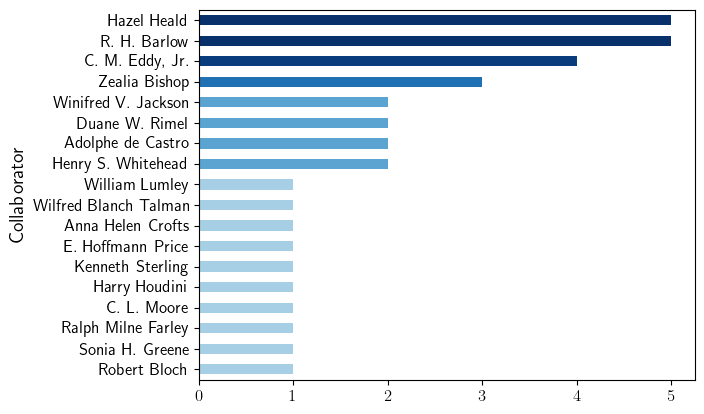

In [243]:
# blue pallete
colors = plt.cm.Blues(0.15 + df_collab['Texts'] / df_collab['Texts'].max())  

# generates a horizontal bar plot
df_collab.plot( kind='barh',        # horizontal bar plot
                x='Collaborator',   # collaborator
                y='Texts',          # number of texts
                legend=False,       # legend
                color=colors)       # colors

# saves the figure
plt.savefig('plots/collaborators_bar_plot.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)

# displays the plot
plt.show()

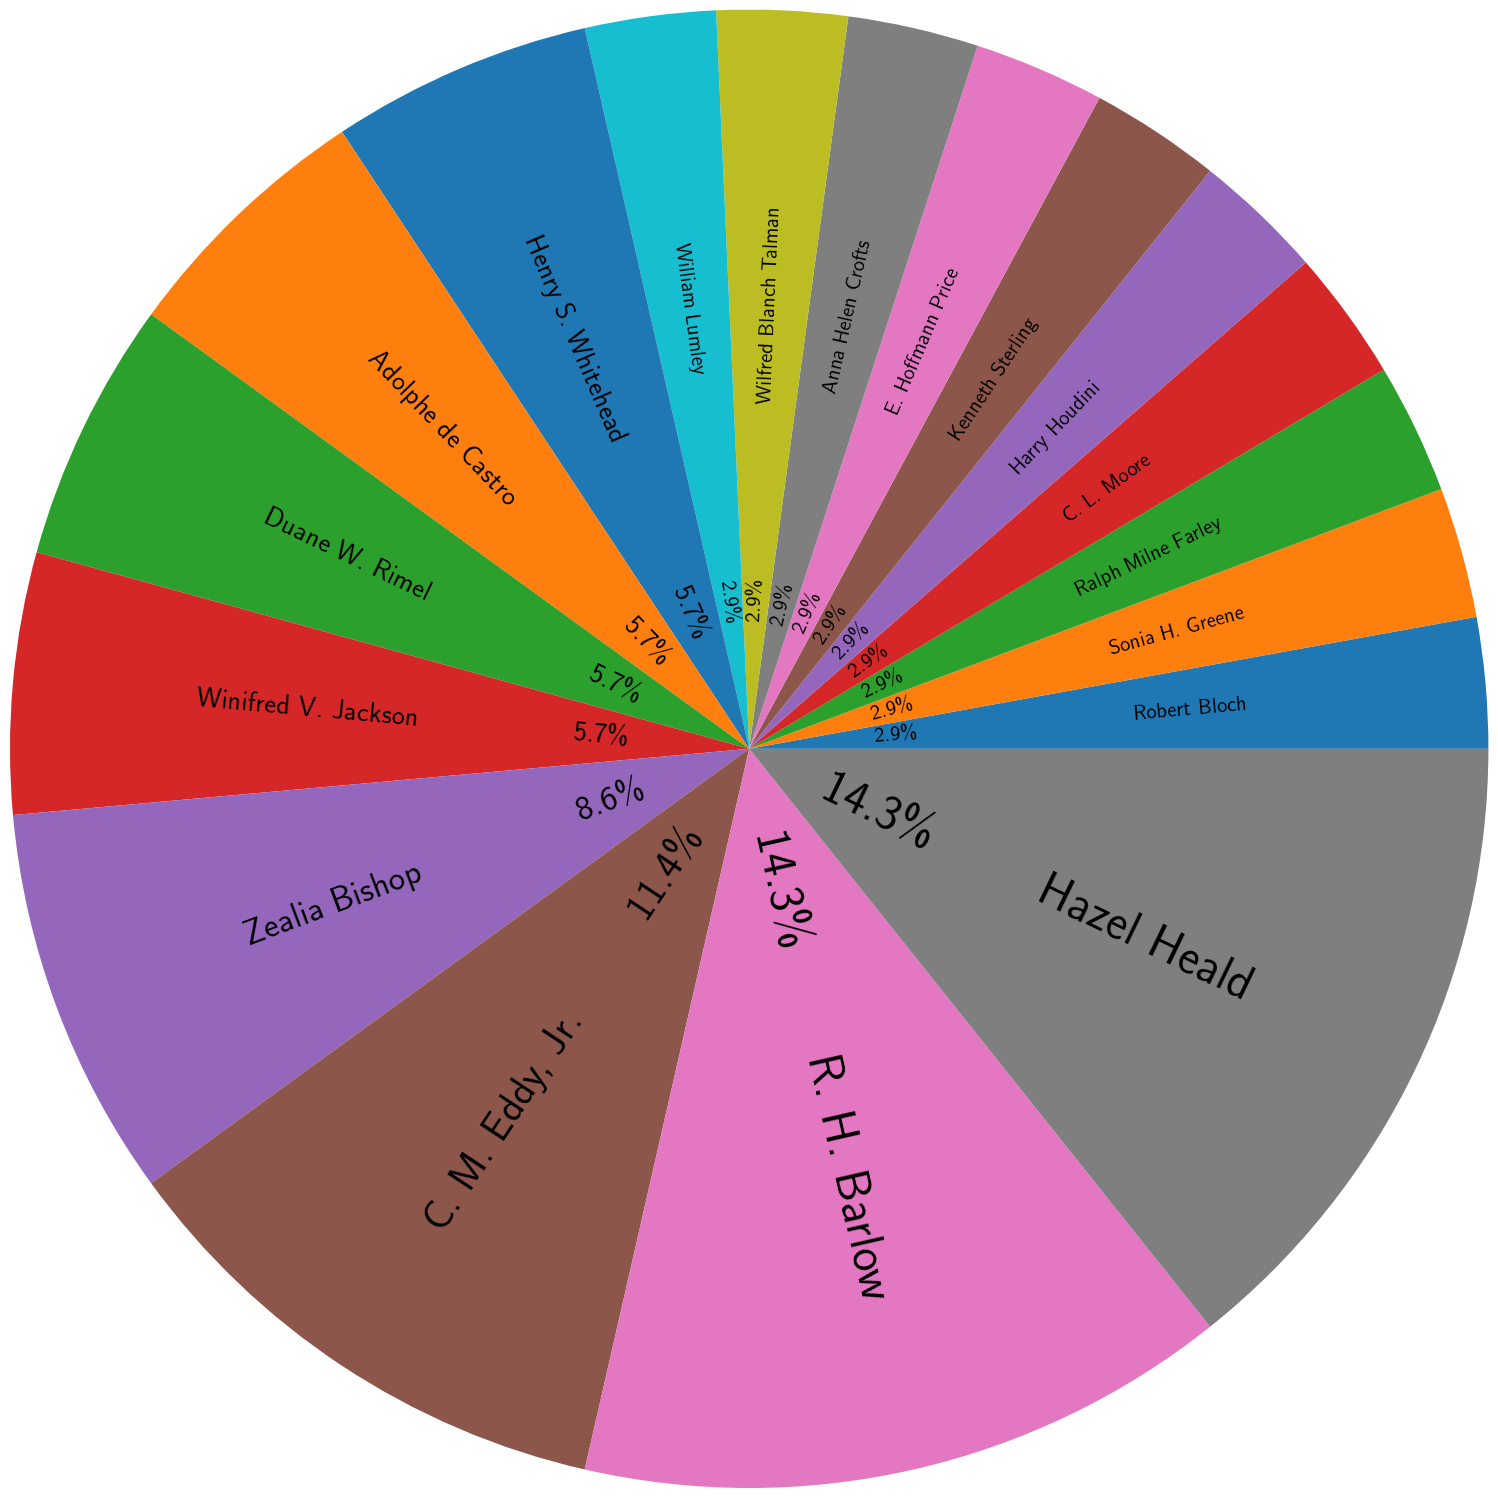

In [244]:
# Custom calibration factor for text sizes (adjust this value)
text_size_scale = 2.0   # increase or decrease to scale all dynamic text sizes

# generates a figure
fig, ax = plt.subplots( figsize = (8,8) )
# Pie Plot
wedges, texts, autotexts = ax.pie(
    df_collab['Texts'],
    labels=df_collab['Collaborator'],      # information for pie plot
    radius=3,                              # circle radius
    autopct="%1.1f%%",                     # auto percentage
    labeldistance=0.6,                     # label distance from the center
    pctdistance=0.2                        # controls position of percentages
)

# Rotates labels and percentages with a single loop
for wedge, text, autotext in zip(wedges, texts, autotexts):
    angle = (wedge.theta1 + wedge.theta2) / 2

    # rotation
    if 90 < angle < 270:
        angle += 180

    # implements the rotation
    text.set_rotation(angle)
    text.set_horizontalalignment('center')

    # scales font size with percentage and global calibration
    percentage = (wedge.theta2 - wedge.theta1) / 360 * 100
    text.set_fontsize((5 + percentage * 0.9) * text_size_scale)

    # keeps the percentage with the exact same angle as the text
    autotext.set_rotation(angle)
    autotext.set_horizontalalignment('center')
    autotext.set_verticalalignment('center')
    autotext.set_fontsize((5 + percentage * 0.9) * text_size_scale)

# saves the figure
plt.savefig('plots/collaborators_pie_plot.png', dpi = 300, bbox_inches='tight', pad_inches=0.2)

# displays the plot
plt.show()

## 2 - Entities informations

We import the dataframe for the entities created in $\tt 02\_bibliographic\_clean.ipynb$

In [245]:
entities_df = pd.read_csv('data/gold/entities.csv')

Now we plot the informations with respect to this dataframe

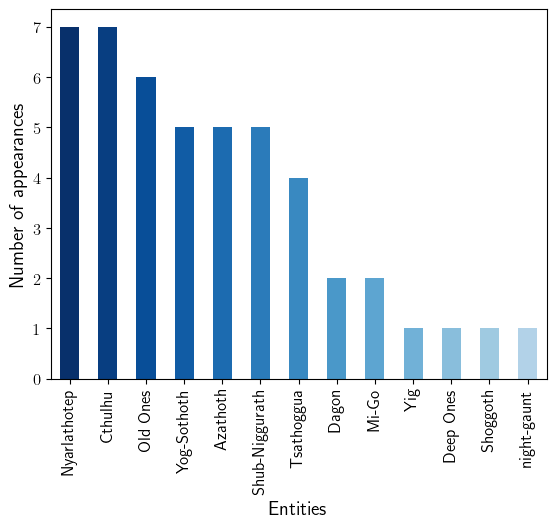

In [246]:
colors = plt.cm.Blues(np.linspace(1, 0.2, len('number_of_texts')))
entities_df = entities_df.sort_values(by='number_of_texts', ascending=False)
entities_df.plot(kind='bar',x='name',y='number_of_texts',color = colors,legend=False)
plt.xlabel('Entities')
plt.ylabel('Number of appearances')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Nyarlathotep'),
  Text(1, 0, 'Cthulhu'),
  Text(2, 0, 'Old Ones'),
  Text(3, 0, 'Yog-Sothoth'),
  Text(4, 0, 'Azathoth'),
  Text(5, 0, 'Shub-Niggurath'),
  Text(6, 0, 'Tsathoggua'),
  Text(7, 0, 'Dagon'),
  Text(8, 0, 'Mi-Go'),
  Text(9, 0, 'Yig'),
  Text(10, 0, 'Deep Ones'),
  Text(11, 0, 'Shoggoth'),
  Text(12, 0, 'night-gaunt')])

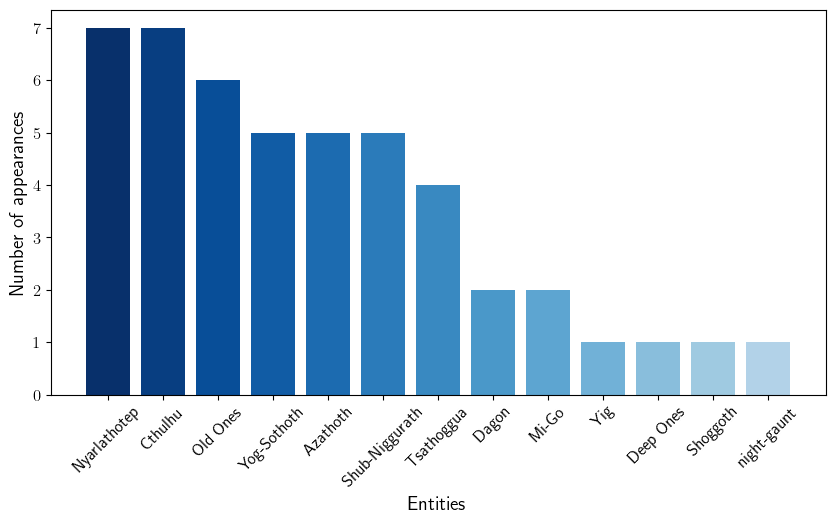

In [247]:
fig, ax = plt.subplots(figsize = (10,5))

ax.bar(entities_df['name'], entities_df['number_of_texts'], color = plt.cm.Blues(np.linspace(1, 0.2, len('number_of_texts'))))
ax.set_xlabel('Entities',fontsize = 14)
ax.set_ylabel('Number of appearances',fontsize = 14)
plt.xticks(rotation=45)

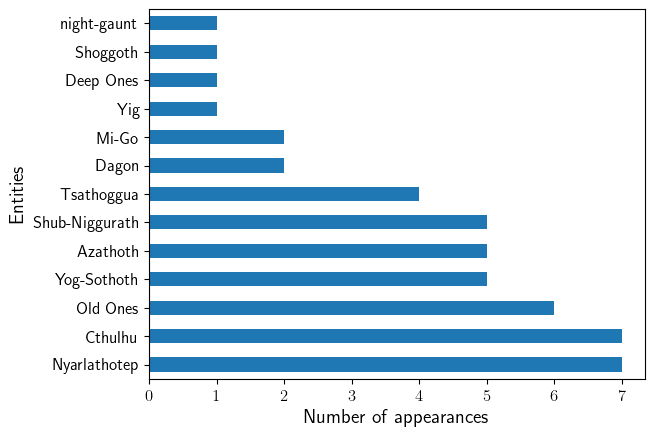

In [248]:
entities_df.plot(kind='barh',x='name',y='number_of_texts',legend=False)
plt.xlabel('Number of appearances')
plt.ylabel('Entities')
plt.show()

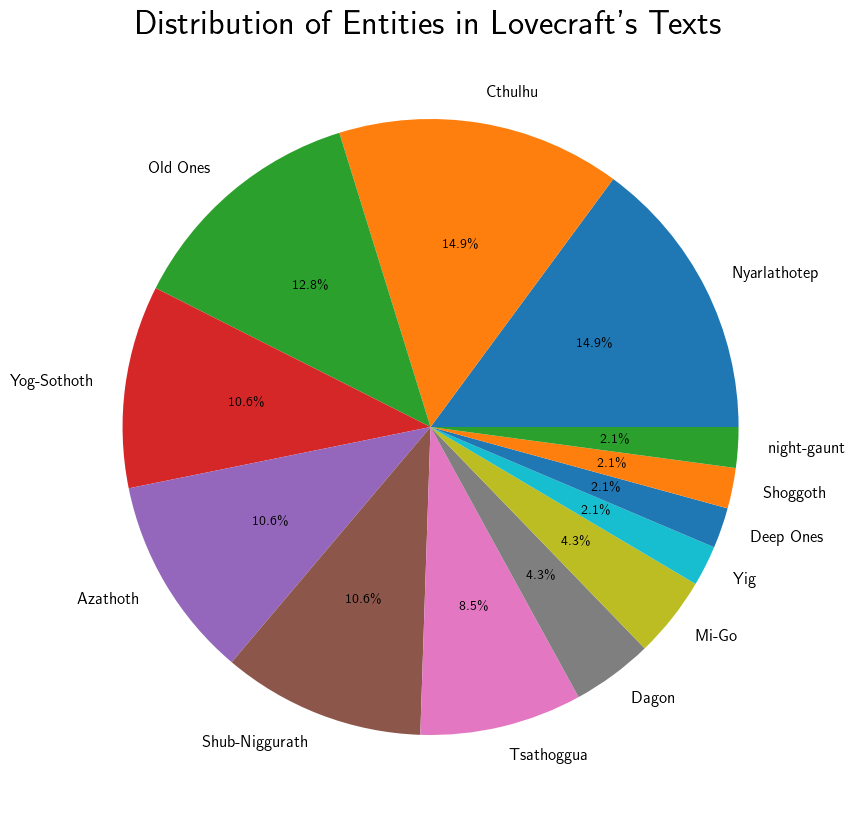

In [249]:
# plotting a pie chart of the distribution of entities in the texts
plt.figure(figsize=(10,10)) # sets the figure size

# organizing by highest number of appearances
entities_df = entities_df.sort_values(by='number_of_texts', ascending=False)

# plotting the absolute values, not the percentages, to avoid the problem of small percentages being invisible in the pie chart
plt.pie(entities_df['number_of_texts'], labels=entities_df['name'], autopct='%1.1f%%') # creates a pie chart with labels and percentages
plt.title('Distribution of Entities in Lovecraft\'s Texts') # sets the title of the plot
plt.show() # displays the plot


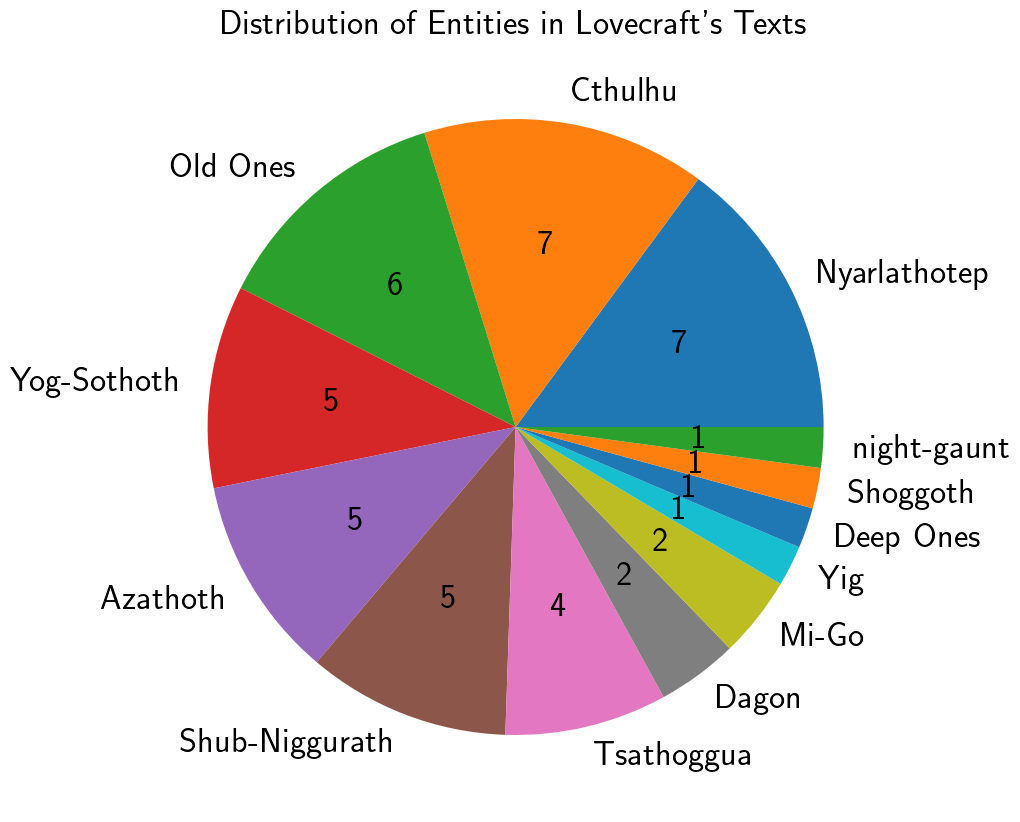

In [250]:
# plotting a pie chart of the distribution of entities in the texts
fig, ax = plt.subplots(figsize=(10,10)) # sets the figure size

# organizing by highest number of appearances
entities_df = entities_df.sort_values(by='number_of_texts', ascending=False)

# plotting the absolute values in each slice label instead of percentages
total = entities_df['number_of_texts'].sum()
wedges, texts, autotexts = ax.pie(
    entities_df['number_of_texts'],
    labels=entities_df['name'],
    autopct=lambda pct: str(int(round(pct * total / 100))),
    textprops={'fontsize': 25}
)

# custom legend showing entity names and counts with a larger font size
legend_labels = [f"{name}: {count}" for name, count in zip(entities_df['name'], entities_df['number_of_texts'])]


ax.set_title('Distribution of Entities in Lovecraft\'s Texts') # sets the title of the plot
plt.setp(autotexts, size=25, weight='bold')
plt.show() # displays the plot
